In [ ]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)
import matplotlib.pyplot as plt
import lightgbm as lgb
from lightgbm import LGBMClassifier

## ANALISIS DEL CSV

In [2]:
CSV_HOTEL_PATH = "../../data/raw/dataset.csv"
df_hotel = pd.read_csv(CSV_HOTEL_PATH)

In [3]:
# Show data
df_hotel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
df_hotel.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [4]:
df_hotel.shape


(119390, 32)

In [5]:
#df_hotel.head(20).T
df_hotel.tail(10).T

,119380,119381,119382,119383,119384,119385,119386,119387,119388,119389
hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel
is_canceled,0,0,0,0,0,0,0,0,0,0
lead_time,44,188,135,164,21,23,102,34,109,205
arrival_date_year,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017
arrival_date_month,August,August,August,August,August,August,August,August,August,August
arrival_date_week_number,35,35,35,35,35,35,35,35,35,35
arrival_date_day_of_month,31,31,30,31,30,30,31,31,31,29
stays_in_weekend_nights,1,2,2,2,2,2,2,2,2,2
stays_in_week_nights,3,3,4,4,5,5,5,5,5,7
adults,2,2,3,2,2,2,3,2,2,2


In [38]:
# df_hotel.describe(include="number").T
df_hotel['customer_type'].describe().T

count        119390
unique            4
top       Transient
freq          89613
Name: customer_type, dtype: object

In [40]:
df_hotel['customer_type'].isna().sum()

0

In [23]:
print(f"Country number: {df_hotel['country'].value_counts(normalize=True)}")
print(f"Null countries: {df_hotel['country'].isna().sum()}")
print(f"Meal number: {df_hotel['meal'].value_counts(normalize=True)}")

Country number: country
PRT    0.408656
GBR    0.102008
FRA    0.087593
ESP    0.072059
DEU    0.061286
         ...   
DJI    0.000008
BWA    0.000008
HND    0.000008
VGB    0.000008
NAM    0.000008
Name: proportion, Length: 177, dtype: float64
Null countries: 488
Meal number: meal
BB           0.773180
HB           0.121141
SC           0.089203
Undefined    0.009791
FB           0.006684
Name: proportion, dtype: float64


In [8]:
precio_negativo = df_hotel[df_hotel['adr'] < 0]
precio_negativo.T

,14969
hotel,Resort Hotel
is_canceled,0
lead_time,195
arrival_date_year,2017
arrival_date_month,March
arrival_date_week_number,10
arrival_date_day_of_month,5
stays_in_weekend_nights,4
stays_in_week_nights,6
adults,2


In [9]:
df_hotel['is_canceled'].value_counts(normalize=True)

is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64

In [ ]:

num_df = df_hotel.select_dtypes(include=['number'])
numeric_columns = num_df.columns
print(f"Numeric columns: {numeric_columns}")
object_df = df_hotel.select_dtypes(include=['object'])
object_columns = object_df.columns
print(f"Object / Categorical columns: {object_columns}")

print(f"{df_hotel.isnull().sum()}")
df_hotel[df_hotel.duplicated(keep=False)]
cols_con_negativos = num_df.columns[(num_df < 0).any()].tolist()
print(f"Cols with negative values: {cols_con_negativos}")


Numeric columns: Index(['is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')
Object / Categorical columns: Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date'],
      dtype='object')
hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival

In [11]:
print(f"Number of categories by column:\n{df_hotel.select_dtypes(include='object').nunique().sort_values(ascending=False)}")
print("")
for i in range(len(object_columns)):
    if (df_hotel[object_columns[i]] == 'Undefined').sum() > 0:
        print(f"Count of {object_columns[i]} 'undefined' : {(df_hotel[object_columns[i]] == 'Undefined').sum()}")

Number of categories by column:
reservation_status_date    926
country                    177
arrival_date_month          12
assigned_room_type          12
reserved_room_type          10
market_segment               8
meal                         5
distribution_channel         5
customer_type                4
deposit_type                 3
reservation_status           3
hotel                        2
dtype: int64



## PREPROCESAMIENTO DE DATOS

In [3]:
df_hotel_prep = df_hotel.copy()

In [23]:
# for i in range(len(object_columns)):
#     print(f"COLUMN {object_columns[i]}: {df_hotel_prep[object_columns[i]].unique()}")

print(f"{df_hotel_prep['distribution_channel'].value_counts()}")
print(f"{df_hotel_prep['meal'].value_counts()}")
print(f"{df_hotel_prep['market_segment'].value_counts()}")
print(f"{df_hotel_prep['country'].value_counts()}")
print(f"Count of reserved_room_type : {df_hotel_prep['reserved_room_type'].value_counts()}")
print(f"Count of assigned_room_type : {df_hotel_prep['assigned_room_type'].value_counts()}")
print(f"Count of adr price unique: {df_hotel_prep['adr'].unique()}")
print(f"Count of adr price == 1: {(df_hotel_prep['adr'] == 1).value_counts()}")
print(f"Count of adr price between 0 and 10: {(df_hotel_prep['adr'].between(0, 11)).value_counts()}")
print(f"Count of adr price < 0: {(df_hotel_prep['adr'] < 0).value_counts()}")

print(f"Count of distribution_channel: {(df_hotel_prep['distribution_channel']).sum()}")
print(f"Count of distribution_channel 'undefined' : {(df_hotel_prep['distribution_channel'] == 'Undefined').sum()}")
print(f"Count of meal 'undefined' : {(df_hotel_prep['meal'] == 'Undefined').sum()}")
print(f"Count of market_segment 'undefined' : {(df_hotel_prep['market_segment'] == 'Undefined').sum()}")
print(f"Count of country under 10% : {(df_hotel_prep['country'].value_counts(normalize=True) <= 0.1).sum()}")

distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64
country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
       ...  
DJI        1
BWA        1
HND        1
VGB        1
NAM        1
Name: count, Length: 177, dtype: int64
Count of reserved_room_type : reserved_room_type
A    85994
D    19201
E     6535
F     2897
G     2094
B     1118
C      932
H      601
P       12
L        6
Name: count, dtype: int64
Count of assigned_room_type : assigned_room_type
A    74053
D    25322
E     7806
F     3751
G     2553
C     2375
B     2163
H     

In [4]:
# PREPROCESING
# children null -> lets say 0 childrens OK
# country null or < 10% -> Grupo 'others' (grupos = df.groupby(df['precio'] > 100)['precio'].count()) OK
# agent -> Value 0 if null value OK
# company null -> remove (+90% null) OK
# Remove duplicates OK

# Hotel, meal ->  OrdinalEncoder (remove undefined)
# country -> Grouping ( <= 10% (175) or > 10% (2)) OrdinalEncoder
# market_segment -> OrdinalEncoder (remove undefined)
# distribution_channel -> OrdinalEncoder (remove undefined)
# reserved_room_type and assigned_room_type -> OrdinalEncoder
# deposit_type -> OrdinalEncoder
# deposit_type -> OrdinalEncoder
#columnas_drop = [
#    'arrival_date_year',          # Sobreajusta a años concretos
#    'arrival_date_week_number',   # Redundante con mes
#    'arrival_date_day_of_month',  # Ruido
#    'reservation_status_date',    # Es post-evento, data leakage
#]#
# Remove duplicates
print(f"Shape before removing duplicates: {df_hotel_prep.shape}")
print(f"Duplicated number before: {df_hotel_prep.duplicated(keep=False).sum()}")
df_hotel_prep = df_hotel_prep.drop_duplicates(keep='first').reset_index(drop=True)
print(f"Shape after removing duplicates: {df_hotel_prep.shape}")
print(f"Duplicated number after: {df_hotel_prep.duplicated(keep=False).sum()}")

Shape before removing duplicates: (119390, 32)
Duplicated number before: 40165
Shape after removing duplicates: (87396, 32)
Duplicated number after: 0


In [7]:
# Sustituir valores de niños null con 0 (asumimos null como 0)
print(f"Null values of children before: {df_hotel_prep['children'].isna().sum()}")
df_hotel_prep['children'] = df_hotel_prep['children'].fillna(0)
print(f"Null values of children after: {df_hotel_prep['children'].isna().sum()}")

Null values of children before: 0
Null values of children after: 0


In [ ]:
df_hotel_prep.drop(columns=['company'], inplace=True)


In [9]:

df_hotel_prep = df_hotel_prep[df_hotel_prep['adr'] >= 0].reset_index(drop=True)

df_hotel_prep = df_hotel_prep[
    df_hotel_prep['adults'].fillna(0) + df_hotel_prep['children'].fillna(0) + df_hotel_prep['babies'].fillna(0) > 0
].reset_index(drop=True)

print(f"Shape tras limpieza de filas inválidas: {df_hotel_prep.shape}")

Shape tras limpieza de filas inválidas: (87229, 31)


In [10]:
# Agrupar los paises con frecuencia < 1%
frequencies = df_hotel_prep['country'].value_counts(normalize=True)
index_low_frequency = frequencies[frequencies < 0.01].index
df_hotel_prep['country'] = np.where(
    df_hotel_prep['country'].isna() | df_hotel_prep['country'].isin(index_low_frequency),
    'Others',
    df_hotel_prep['country']
)
print(f"{df_hotel_prep['country'].value_counts(normalize=True)}")

country
PRT       0.313600
Others    0.119937
GBR       0.119490
FRA       0.101148
ESP       0.083046
DEU       0.061734
ITA       0.035092
IRL       0.034564
BEL       0.023857
BRA       0.022848
NLD       0.021896
USA       0.021449
CHE       0.017953
CN        0.012530
AUT       0.010856
Name: proportion, dtype: float64


In [11]:
# 'Undefined' se conserva como categoría propia — agrupar solo los de frecuencia < 1%
frequencies = df_hotel_prep['distribution_channel'].value_counts(normalize=True)
index_low_frequency = frequencies[frequencies < 0.01].index
df_hotel_prep['distribution_channel'] = np.where(
    df_hotel_prep['distribution_channel'].isin(index_low_frequency),
    'Others',
    df_hotel_prep['distribution_channel']
)
print(f"{df_hotel_prep['distribution_channel'].value_counts(normalize=True)}")

distribution_channel
TA/TO        0.791342
Direct       0.148494
Corporate    0.058031
Others       0.002132
Name: proportion, dtype: float64


In [12]:
# Agrupar las habitaciones reservadas con frecuencia <= 1%
frequencies = df_hotel_prep['reserved_room_type'].value_counts(normalize=True)
index_low_frequency = frequencies[frequencies <= 0.01].index
df_hotel_prep['reserved_room_type'] = np.where(
    df_hotel_prep['reserved_room_type'].isin(index_low_frequency),
    'Others',
    df_hotel_prep['reserved_room_type']
)
print(f"{df_hotel_prep['reserved_room_type'].value_counts(normalize=True)}")

reserved_room_type
A         0.646975
D         0.199200
E         0.069197
F         0.032329
G         0.023501
B         0.011418
C         0.010478
Others    0.006901
Name: proportion, dtype: float64


In [13]:
# Agrupar las habitaciones asignadas con frecuencia <= 1%
frequencies = df_hotel_prep['assigned_room_type'].value_counts(normalize=True)
index_low_frequency = frequencies[frequencies <= 0.01].index
df_hotel_prep['assigned_room_type'] = np.where(
    df_hotel_prep['assigned_room_type'].isin(index_low_frequency),
    'Others',
    df_hotel_prep['assigned_room_type']
)
print(f"{df_hotel_prep['assigned_room_type'].value_counts(normalize=True)}")

assigned_room_type
A         0.530592
D         0.257013
E         0.082427
F         0.041580
G         0.028603
C         0.024762
B         0.020761
Others    0.014261
Name: proportion, dtype: float64


In [14]:
df_hotel_prep['agent_known'] = df_hotel_prep['agent'].notna().astype(int)
df_hotel_prep.drop(columns=['agent'], inplace=True)

In [15]:
# Columnas categóricas que serán codificadas con OrdinalEncoder tras el split
category_columns = ['hotel', 'meal', 'country', 'market_segment', 'distribution_channel',
                    'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']
# OrdinalEncoder se aplica post-split para evitar leakage

In [35]:
df_hotel_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86899 entries, 0 to 86898
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           86899 non-null  float64
 1   is_canceled                     86899 non-null  int64  
 2   lead_time                       86899 non-null  int64  
 3   arrival_date_year               86899 non-null  int64  
 4   arrival_date_month              86899 non-null  object 
 5   arrival_date_week_number        86899 non-null  int64  
 6   arrival_date_day_of_month       86899 non-null  int64  
 7   stays_in_weekend_nights         86899 non-null  int64  
 8   stays_in_week_nights            86899 non-null  int64  
 9   adults                          86899 non-null  int64  
 10  children                        86899 non-null  float64
 11  babies                          86899 non-null  int64  
 12  meal                            

In [16]:
MONTHS = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
          'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}
df_hotel_prep['arrival_date_month'] = df_hotel_prep['arrival_date_month'].map(MONTHS)

drop_columns = [
    'arrival_date_year',        # Sobreajusta a años concretos
    'arrival_date_week_number', # Redundante con mes
    'reservation_status_date',  # Es post-evento, data leakage
    'reservation_status',       # Puede provocar overfitting
]
df_hotel_prep.drop(columns=drop_columns, inplace=True)

In [17]:
print(f"Shape after preprocessing: {df_hotel_prep.shape}")
df_hotel_prep.info()

Shape after preprocessing: (87229, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87229 entries, 0 to 87228
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87229 non-null  object 
 1   is_canceled                     87229 non-null  int64  
 2   lead_time                       87229 non-null  int64  
 3   arrival_date_month              87229 non-null  int64  
 4   arrival_date_day_of_month       87229 non-null  int64  
 5   stays_in_weekend_nights         87229 non-null  int64  
 6   stays_in_week_nights            87229 non-null  int64  
 7   adults                          87229 non-null  int64  
 8   children                        87229 non-null  float64
 9   babies                          87229 non-null  int64  
 10  meal                            87229 non-null  object 
 11  country                         87229 non-null  object

#### Obtener variables X e y

In [18]:
random_state=11
target_column = 'is_canceled'
X = df_hotel_prep.drop(columns=[target_column])
y = df_hotel_prep[target_column]

print(f"Percentage y: {y.value_counts(normalize=True)}")

Percentage y: is_canceled
0    0.724759
1    0.275241
Name: proportion, dtype: float64


In [ ]:
leaves = 31
lr = 0.1
estimators = 100
# reg_alpha : float, optional (default=0.)
# L1 regularization term on weights.

# reg_lambda : float, optional (default=0.)
# L2 regularization term on weights.
#  class_weight='balanced'
model_lgb = LGBMClassifier(num_leaves=leaves, learning_rate=lr, n_estimators=estimators,
                            objective='binary', random_state=random_state)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=y)

# OrdinalEncoder: fit solo con train para evitar leakage
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train[category_columns] = encoder.fit_transform(X_train[category_columns])
X_test[category_columns]  = encoder.transform(X_test[category_columns])

print(f"Train data percentage: {y_train.value_counts(normalize=True)}")
print(f"Test data percentage: {y_test.value_counts(normalize=True)}")

model_lgb.fit(X_train, y_train, categorical_feature=category_columns)

Train data percentage: is_canceled
0    0.724761
1    0.275239
Name: proportion, dtype: float64
Test data percentage: is_canceled
0    0.724751
1    0.275249
Name: proportion, dtype: float64
[LightGBM] [Info] Number of positive: 19207, number of negative: 50576
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008688 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 844
[LightGBM] [Info] Number of data points in the train set: 69783, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.275239 -> initscore=-0.968202
[LightGBM] [Info] Start training from score -0.968202


LGBMClassifier(objective='binary', random_state=11)

In [22]:
y_predict = model_lgb.predict(X_test)

y_predict_proba = model_lgb.predict_proba(X_test)

In [23]:
# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_predict)
prec = precision_score(y_test, y_predict)
rec = recall_score(y_test, y_predict)
f1 = f1_score(y_test, y_predict)

# Cálculo del AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_predict_proba[:, 1])

print(f"Accuracy:  {acc:.2%}")
print(f"Precisión: {prec:.2%}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

Accuracy:  83.47%
Precisión: 73.87%
Recall:    0.62
F1-Score:  0.67
AUC:       0.90



In [24]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_predict))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.86      0.92      0.89     12644
           1       0.74      0.62      0.67      4802

    accuracy                           0.83     17446
   macro avg       0.80      0.77      0.78     17446
weighted avg       0.83      0.83      0.83     17446



#### Prueba con GridSearchCV
Mejor resultado

param_grid = {
    'max_iter': [300, 400, 600, 800, 1000],
    'penalty': ['l1'], # Lasso. No hay muchas columnas
    'C': [0.05, 0.1, 0.2, 0.5, 1.0],
    'solver': ['liblinear']
}
multimetrics = ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']
refit = 'roc_auc'

Mejores hiperparámetros: {'C': 1.0, 'max_iter': 300, 'penalty': 'l1', 'solver': 'liblinear'}
Mejor puntuación de validación cruzada: 0.7570615093542241


In [ ]:
param_grid = {
    'num_leaves': [31, 60, 100, 200] ,
    'learning_rate': [0.1, 0.5, 0.7, 1.0],
    'n_estimators': [100, 250, 400, 600]
}
# multimetrics = ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']
scoring = 'recall'
# Elijo recall porque quiero atrapar a todos los que pueden cancelar. no quiero falsos negativos
model_gs = GridSearchCV(model_lgb, cv=5, scoring=scoring, param_grid=param_grid)
model_gs.fit(X_train, y_train)

print(f"Mejores hiperparámetros: {model_gs.best_params_}")
print(f"Mejor puntuación de validación cruzada: {model_gs.best_score_}")
best_model_lgb = model_gs.best_estimator_

[LightGBM] [Info] Number of positive: 15331, number of negative: 40284
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010385 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 950
[LightGBM] [Info] Number of data points in the train set: 55615, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.275663 -> initscore=-0.966077
[LightGBM] [Info] Start training from score -0.966077
[LightGBM] [Info] Number of positive: 15330, number of negative: 40285
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003734 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 945
[LightGBM] [Info] Number of data points in the train set: 55615, number of used features: 24
[LightGBM] [Info] [b

In [ ]:
print(f"Clases modelo: {best_model_lgb.classes_}")

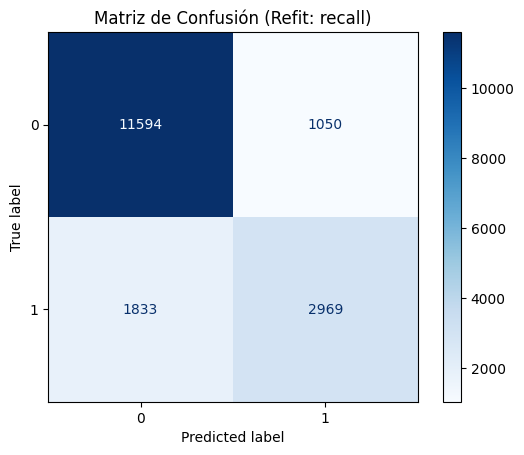

In [25]:
cm = confusion_matrix(y_test, y_predict)

# 3. Mostrarla de forma visual y bonita
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_lgb.classes_)
disp.plot(cmap='Blues')

plt.title(f'Matriz de Confusión (Refit: recall)')
plt.show()

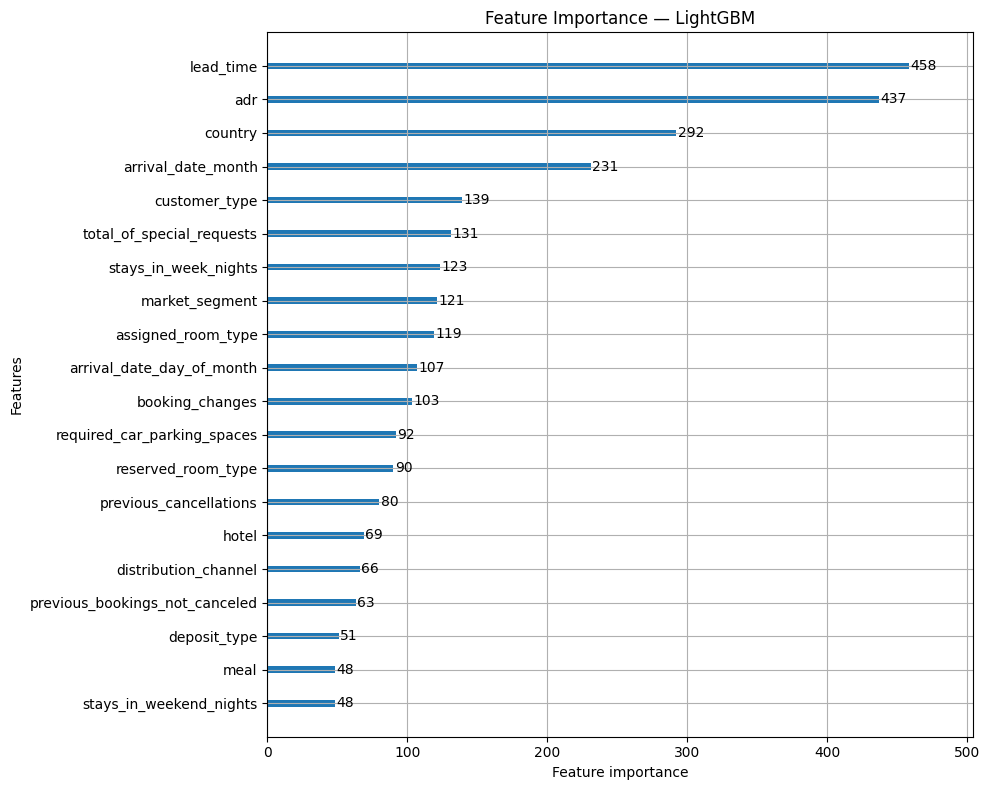

In [27]:
# Importancia de features del mejor modelo LightGBM
lgb.plot_importance(model_lgb, figsize=(10, 8), title='Feature Importance — LightGBM', max_num_features=20)
plt.tight_layout()
plt.show()

In [28]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_predict_proba[:, 1])
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

NameError: name 'roc_curve' is not defined